# GAN - ArtBench

## Imports

In [1]:
from __future__ import annotations

import sys
import csv
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms 
from torchvision.utils import make_grid

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

import random
'''
seed = random.randint(0, 500)
set_seed(seed)
print(f"Using seed: {seed}")'''

seed=3
set_seed(seed)

In [3]:
IMAGE_SIZE = 32
BATCH_SIZE = 64

# Number of channels in the training images. For color images this is 3
nc = 3

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

In [4]:
DEVIDE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVIDE)


Device: cuda


## Dataset

In [5]:
def find_project_root(start: Path, markers: list[str], max_levels: int = 6) -> Path:
    """Sobe na árvore de pastas até encontrar uma pasta que contenha todos os markers."""
    path = start
    for _ in range(max_levels):
        if all((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise RuntimeError(
        f"PROJECT_ROOT não encontrado a partir de {start}.\n"
        "Estrutura esperada: pasta com 'ArtBench-10/' e 'TP1-alunos-src-only/'."
    )

PROJECT_ROOT      = find_project_root(Path(".").resolve(), ["ArtBench-10", "TP1-alunos-src-only"])
SCRIPTS_DIR       = PROJECT_ROOT / "TP1-alunos-src-only" / "scripts"
KAGGLE_ROOT       = PROJECT_ROOT / "ArtBench-10"
TRAINING_CSV_PATH = PROJECT_ROOT / "TP1-alunos-src-only" / "student_start_pack" / "training_20_percent.csv"

print("PROJECT_ROOT   =", PROJECT_ROOT)
print("SCRIPTS_DIR    =", SCRIPTS_DIR)
print("KAGGLE_ROOT    =", KAGGLE_ROOT)
print("TRAINING CSV   =", TRAINING_CSV_PATH)

assert SCRIPTS_DIR.exists(), f"Não existe: {SCRIPTS_DIR}"
assert KAGGLE_ROOT.exists(), f"Não existe: {KAGGLE_ROOT}"
assert TRAINING_CSV_PATH.exists(), f"Não existe: {TRAINING_CSV_PATH}"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))


PROJECT_ROOT   = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1
SCRIPTS_DIR    = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\TP1-alunos-src-only\scripts
KAGGLE_ROOT    = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\ArtBench-10
TRAINING CSV   = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\TP1-alunos-src-only\student_start_pack\training_20_percent.csv


In [6]:
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_dataset_completo = hf_ds["train"]

print("Número total de imagens de treino:", len(train_dataset_completo))
print("Colunas:", train_dataset_completo.column_names)

label_feature = train_dataset_completo.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)

print("Número de classes:", num_classes)
print("Classes:", class_names)

Dataset source: kaggle root='D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\ArtBench-10'
Número total de imagens de treino: 50000
Colunas: ['image', 'label']
Número de classes: 10
Classes: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [7]:
transform=transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform is not None else img
        return x, y, real_idx

def denorm(x):
    '''inverte a normalização Normalize(0.5, 0.5, 0.5) que foi aplicada no transform. As imagens foram guardadas em [-1, 1] (necessário para o Tanh() do gerador), e esta função converte de volta para [0, 1] para poder visualizar com matplotlib.'''
    return (x * 0.5 + 0.5).clamp(0, 1)

In [8]:
INDEX_COLUMN = "train_id_original"

def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    ids = []
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        if index_column not in (reader.fieldnames or []):
            raise ValueError(f"Coluna {index_column!r} não encontrada. Disponíveis: {reader.fieldnames}")
        for row in reader:
            value = str(row.get(index_column, "")).strip()
            if value:
                ids.append(int(value))
    if len(ids) == 0:
        raise ValueError("Não foram lidos IDs do CSV.")
    return ids

train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, INDEX_COLUMN)

print("Número de IDs lidos do CSV:", len(train_ids_from_csv))
print("Primeiros 10 IDs:", train_ids_from_csv[:10])

Número de IDs lidos do CSV: 10000
Primeiros 10 IDs: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]


In [9]:
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.


In [10]:
train_subset = HFDatasetTorch(train_dataset_completo, transform=transform, indices=train_ids_from_csv)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Tamanho do subset:", len(train_subset))
print("Número de batches:", len(train_loader))


Tamanho do subset: 10000
Número de batches: 157


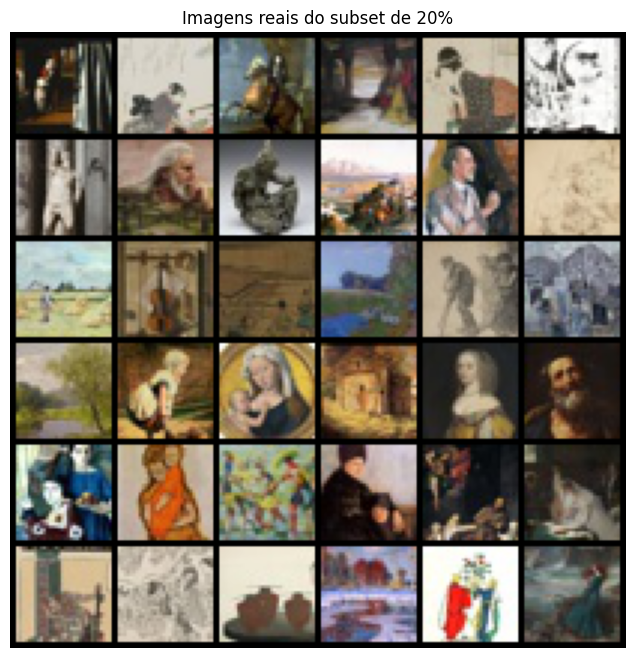

Exemplos de labels:
0: classe=baroque 
1: classe=ukiyo_e 
2: classe=baroque 
3: classe=surrealism 
4: classe=ukiyo_e 
5: classe=art_nouveau 
6: classe=renaissance 
7: classe=surrealism 
8: classe=surrealism 
9: classe=romanticism 
10: classe=impressionism 
11: classe=post_impressionism 


In [11]:
x, y, idx = next(iter(train_loader))

grid = make_grid(denorm(x[:36]), nrow=6, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Imagens reais do subset de 20%")
plt.show()

print("Exemplos de labels:")
for i in range(min(12, len(y))):
    print(f"{i}: classe={class_names[int(y[i])]} ")

## GAN

https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html#what-is-a-gan

### Weight Initialization

In [12]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [13]:
import torch

@torch.no_grad()
def generate_fake_images(generator, n_samples=5000, batch_size=64, latent_dim=100, device="cuda"):
    generator.eval()
    all_images = []

    total = 0
    while total < n_samples:
        current_batch = min(batch_size, n_samples - total)
        z = torch.randn(current_batch, latent_dim, 1, 1, device=device)
        fake = generator(z).cpu()
        fake = denorm(fake)   # passar de [-1,1] para [0,1]
        all_images.append(fake)
        total += current_batch

    return torch.cat(all_images, dim=0)

In [14]:
@torch.no_grad()
def collect_real_images(dataloader, n_samples=5000):
    all_images = []
    total = 0

    for x, _, _ in dataloader:
        x = denorm(x.cpu())   # passar de [-1,1] para [0,1]
        all_images.append(x)
        total += x.size(0)

        if total >= n_samples:
            break

    return torch.cat(all_images, dim=0)[:n_samples]

In [15]:
!pip install torchmetrics[image]

In [16]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

def to_uint8(x):
    x = (x * 255).clamp(0, 255).to(torch.uint8)
    return x

def compute_fid_kid(real_images, fake_images, device, batch_size=64):
    fid = FrechetInceptionDistance(feature=2048).to(device)
    kid = KernelInceptionDistance(subset_size=100).to(device)

    # processar em mini-batches para não esgotar a VRAM
    for start in range(0, len(real_images), batch_size):
        batch = to_uint8(real_images[start:start + batch_size]).to(device)
        fid.update(batch, real=True)
        kid.update(batch, real=True)

    for start in range(0, len(fake_images), batch_size):
        batch = to_uint8(fake_images[start:start + batch_size]).to(device)
        fid.update(batch, real=False)
        kid.update(batch, real=False)

    fid_value = fid.compute().item()
    kid_mean, kid_std = kid.compute()

    return {
        "fid": fid_value,
        "kid_mean": kid_mean.item(),
        "kid_std": kid_std.item()
    }

## Otimização de hiperparâmetros com Optuna

Nesta secção, usamos o **Optuna** para procurar automaticamente bons valores para:

- `nz`
- `ngf`
- `ndf`
- `lr_G`
- `lr_D`
- `beta1`

A pesquisa usa **poucas épocas por tentativa** para ser mais rápida.  
Depois de encontrar a melhor configuração, fazemos um **treino final** com mais épocas.

> Nota: neste notebook, o objetivo do Optuna usa uma métrica rápida baseada na loss do gerador nas últimas iterações.  
> Para avaliação final, continua a ser recomendável usar **FID/KID** no melhor modelo.

In [17]:
!pip install -q optuna

In [18]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

In [ ]:
# Configuração da pesquisa Optuna
SEARCH_TRIALS = 15          # número de tentativas
SEARCH_EPOCHS = 10          # épocas por tentativa
FINAL_EPOCHS = 50           # treino final com os melhores parâmetros
OPTUNA_TIMEOUT = None       # ex.: 3600 para parar ao fim de 1h

# Número de batches usados por trial.
# Se quiseres acelerar ainda mais, reduz este valor (ex.: 80 ou 100).
MAX_BATCHES_PER_TRIAL = None

# Mesma lógica do gan_lr_diferentes: escolher hiperparâmetros por FID/KID.
# 5000 replica exatamente a avaliação final; reduz para 1000-2000 se quiseres acelerar.
OPTUNA_METRIC_SAMPLES = 5000
OPTUNA_OBJECTIVE = "fid"  # opções: "fid" ou "fid_plus_kid"

In [20]:
class GeneratorOptuna(nn.Module):
    def __init__(self, nz, ngf, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)


class DiscriminatorOptuna(nn.Module):
    def __init__(self, ndf, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)


def build_dcgan_models(nz, ngf, ndf, device, ngpu=1, nc=3):
    netG = GeneratorOptuna(nz=nz, ngf=ngf, nc=nc).to(device)
    netD = DiscriminatorOptuna(ndf=ndf, nc=nc).to(device)

    if (device.type == "cuda") and (ngpu > 1):
        netG = nn.DataParallel(netG, list(range(ngpu)))
        netD = nn.DataParallel(netD, list(range(ngpu)))

    netG.apply(weights_init)
    netD.apply(weights_init)
    return netG, netD

In [21]:
import numpy as np
import torchvision.utils as vutils

def train_gan_once(
    netG, netD, train_loader, criterion, optimizerG, optimizerD,
    nz, num_epochs, real_label, fake_label, fixed_noise, device,
    verbose=True, max_batches=None
):
    img_list = []
    G_losses = []
    D_losses = []
    iters = 0

    for epoch in range(num_epochs):
        for i, data in enumerate(train_loader, 0):
            if max_batches is not None and i >= max_batches:
                break

            # ============================
            # (1) Update D
            # ============================
            netD.zero_grad()
            real_cpu = data[0].to(device)
            b_size = real_cpu.size(0)

            output_real = netD(real_cpu).view(-1)
            errD_real = criterion(output_real, torch.full_like(output_real, real_label))
            errD_real.backward()
            D_x = output_real.mean().item()

            noise = torch.randn(b_size, nz, 1, 1, device=device)
            fake = netG(noise)

            output_fake = netD(fake.detach()).view(-1)
            errD_fake = criterion(output_fake, torch.full_like(output_fake, fake_label))
            errD_fake.backward()
            D_G_z1 = output_fake.mean().item()

            errD = errD_real + errD_fake
            optimizerD.step()

            # ============================
            # (2) Update G
            # ============================
            netG.zero_grad()
            output = netD(fake).view(-1)
            errG = criterion(output, torch.full_like(output, real_label))
            errG.backward()
            D_G_z2 = output.mean().item()
            optimizerG.step()

            G_losses.append(errG.item())
            D_losses.append(errD.item())

            if verbose and i % 50 == 0:
                print(
                    '[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                    % (epoch + 1, num_epochs, i, len(train_loader), errD.item(), errG.item(), D_x, D_G_z1, D_G_z2)
                )

            if (iters % 500 == 0) or ((epoch == num_epochs - 1) and (i == len(train_loader) - 1)):
                with torch.no_grad():
                    fake_fixed = netG(fixed_noise).detach().cpu()
                img_list.append(vutils.make_grid(fake_fixed, padding=2, normalize=True))

            iters += 1

    return G_losses, D_losses, img_list

In [ ]:
def objective(trial):
    # Espaço de pesquisa
    nz_trial = trial.suggest_categorical("nz", [64, 100, 128, 150])
    ngf_trial = trial.suggest_categorical("ngf", [32, 64, 128, 256])
    ndf_trial = trial.suggest_categorical("ndf", [32, 64, 128, 256])

    # Impor restrição: lr_G >= lr_D
    lr_G_trial = trial.suggest_float("lr_G", 1e-5, 5e-4, log=True)
    lr_D_trial = trial.suggest_float("lr_D", 1e-5, lr_G_trial, log=True)
    assert lr_G_trial >= lr_D_trial, f"Invalid setup: lr_G ({lr_G_trial}) must be >= lr_D ({lr_D_trial})"

    beta1_trial = trial.suggest_float("beta1", 0.4, 0.7)

    netG_trial, netD_trial = build_dcgan_models(
        nz=nz_trial, ngf=ngf_trial, ndf=ndf_trial,
        device=DEVIDE, ngpu=ngpu, nc=nc
    )

    criterion_trial = nn.BCELoss()
    optimizerD_trial = torch.optim.Adam(netD_trial.parameters(), lr=lr_D_trial, betas=(beta1_trial, 0.999))
    optimizerG_trial = torch.optim.Adam(netG_trial.parameters(), lr=lr_G_trial, betas=(beta1_trial, 0.999))
    fixed_noise_trial = torch.randn(64, nz_trial, 1, 1, device=DEVIDE)

    G_losses_trial, D_losses_trial, _ = train_gan_once(
        netG_trial, netD_trial, train_loader, criterion_trial,
        optimizerG_trial, optimizerD_trial, nz_trial, SEARCH_EPOCHS,
        real_label=1.0, fake_label=0.0, fixed_noise=fixed_noise_trial,
        device=DEVIDE, verbose=False, max_batches=MAX_BATCHES_PER_TRIAL
    )

    # Mesma lógica do gan_lr_diferentes: avaliar por FID/KID.
    fake_images_trial = generate_fake_images(
        netG_trial,
        n_samples=OPTUNA_METRIC_SAMPLES,
        batch_size=64,
        latent_dim=nz_trial,
        device=DEVIDE,
    )
    real_images_trial = collect_real_images(train_loader, n_samples=OPTUNA_METRIC_SAMPLES)
    metrics_trial = compute_fid_kid(real_images_trial, fake_images_trial, DEVIDE)

    if OPTUNA_OBJECTIVE == "fid_plus_kid":
        score = float(metrics_trial["fid"] + 100.0 * metrics_trial["kid_mean"])
    else:
        score = float(metrics_trial["fid"])

    trial.set_user_attr("fid", float(metrics_trial["fid"]))
    trial.set_user_attr("kid_mean", float(metrics_trial["kid_mean"]))
    trial.set_user_attr("kid_std", float(metrics_trial["kid_std"]))
    trial.set_user_attr("score", score)

    trial.report(score, step=SEARCH_EPOCHS)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return score

In [23]:
study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=0)
)

study.optimize(
    objective,
    n_trials=SEARCH_TRIALS,
    timeout=OPTUNA_TIMEOUT,
    show_progress_bar=True
)

print("Melhor trial:", study.best_trial.number)
print("Melhor score:", study.best_value)
print("Melhores parâmetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-04-23 12:08:39,174] A new study created in memory with name: no-name-eccf2090-0bfd-4ad9-81ea-1978622df58b


  0%|          | 0/15 [00:00<?, ?it/s]

[W 2026-04-23 12:27:37,743] Trial 0 failed with parameters: {'nz': 100, 'ngf': 256, 'ndf': 256, 'lr_G': 0.00025959425503112657, 'lr_D': 1.9966877749248798e-05, 'beta1': 0.4545474901621302} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\ritam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\ritam\AppData\Local\Temp\ipykernel_3556\696649899.py", line 24, in objective
    G_losses_trial, D_losses_trial, _ = train_gan_once(
                                        ^^^^^^^^^^^^^^^
  File "C:\Users\ritam\AppData\Local\Temp\ipykernel_3556\37850849.py", line 29, in train_gan_once
    D_x = output_real.mean().item()
          ^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
[W 2026-04-23 12:27:37,752] Trial 0 failed with value None.


KeyboardInterrupt: 

In [ ]:
optuna_results = study.trials_dataframe()
optuna_results.sort_values("value").head(10)

In [ ]:
OPTUNA_PLOTS_DIR = PROJECT_ROOT / "results_optuna" / "plots"
OPTUNA_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

ax1 = optuna.visualization.matplotlib.plot_optimization_history(study)
ax1.figure.tight_layout()
ax1.figure.savefig(OPTUNA_PLOTS_DIR / "optuna_optimization_history.png", dpi=300, bbox_inches="tight")
plt.show()

ax2 = optuna.visualization.matplotlib.plot_param_importances(study)
ax2.figure.tight_layout()
ax2.figure.savefig(OPTUNA_PLOTS_DIR / "optuna_param_importances.png", dpi=300, bbox_inches="tight")
plt.show()

print("Plots do Optuna guardados em:", OPTUNA_PLOTS_DIR)

## Treino final com os melhores hiperparâmetros

In [ ]:
best_params = study.best_params

best_nz = int(best_params["nz"])
best_ngf = int(best_params["ngf"])
best_ndf = int(best_params["ndf"])
best_lr_G = float(best_params["lr_G"])
best_lr_D = float(best_params["lr_D"])
best_beta1 = float(best_params["beta1"])

# Seed fixa da pesquisa (já usada no TPESampler)
OPTUNA_SEARCH_SEED = 42

# Seeds para o treino final com os melhores hiperparâmetros.
# Altera esta lista conforme quiseres (ex.: [3, 17, 29, 42, 58]).
FINAL_RUN_SEEDS = [3]

print("Configuração final:")
print("nz =", best_nz)
print("ngf =", best_ngf)
print("ndf =", best_ndf)
print("lr_G =", best_lr_G)
print("lr_D =", best_lr_D)
print("beta1 =", best_beta1)
print("Optuna seed =", OPTUNA_SEARCH_SEED)
print("Seeds treino final =", FINAL_RUN_SEEDS)

In [ ]:
from torchvision.utils import save_image, make_grid

RESULTS_DIR = PROJECT_ROOT / "results_optuna"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

final_runs = {}

for run_seed in FINAL_RUN_SEEDS:
    set_seed(run_seed)
    print(f"\n=== Treino final com seed {run_seed} ===")

    run_tag = f"seed_{run_seed}_lr_G{best_lr_G:.2e}_lr_D{best_lr_D:.2e}_latente{best_nz}"
    seed_dir = RESULTS_DIR / run_tag
    seed_dir.mkdir(parents=True, exist_ok=True)

    netG_best, netD_best = build_dcgan_models(
        nz=best_nz, ngf=best_ngf, ndf=best_ndf,
        device=DEVIDE, ngpu=ngpu, nc=nc
    )

    criterion_best = nn.BCELoss()
    optimizerD_best = torch.optim.Adam(netD_best.parameters(), lr=best_lr_D, betas=(best_beta1, 0.999))
    optimizerG_best = torch.optim.Adam(netG_best.parameters(), lr=best_lr_G, betas=(best_beta1, 0.999))
    fixed_noise_best = torch.randn(64, best_nz, 1, 1, device=DEVIDE)

    G_losses_best, D_losses_best, img_list_best = train_gan_once(
        netG_best, netD_best, train_loader, criterion_best,
        optimizerG_best, optimizerD_best, best_nz, FINAL_EPOCHS,
        real_label=1.0, fake_label=0.0, fixed_noise=fixed_noise_best,
        device=DEVIDE, verbose=True, max_batches=None
    )

    ckpt_g_path = seed_dir / f"netG_best_optuna_seed{run_seed}.pth"
    ckpt_d_path = seed_dir / f"netD_best_optuna_seed{run_seed}.pth"
    torch.save(netG_best.state_dict(), ckpt_g_path)
    torch.save(netD_best.state_dict(), ckpt_d_path)

    # Guardar grid de amostras do melhor parâmetro para esta seed
    netG_best.eval()
    with torch.no_grad():
        noise = torch.randn(64, best_nz, 1, 1, device=DEVIDE)
        fake_images = netG_best(noise).cpu()
        fake_images = denorm(fake_images)

    grid = make_grid(fake_images, nrow=8, padding=2)
    grid_path = seed_dir / "grid.png"
    save_image(grid, grid_path)

    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title(f"Amostras geradas_seed_{run_seed}_latente{best_nz}")
    plt.show()
    print("Ficheiros da seed guardados em:", seed_dir)

    final_runs[run_seed] = {
        "G_losses": G_losses_best,
        "D_losses": D_losses_best,
        "seed_dir": str(seed_dir),
        "netG_ckpt": str(ckpt_g_path),
        "netD_ckpt": str(ckpt_d_path),
        "samples_grid_path": str(grid_path)
    }

    del netG_best, netD_best, optimizerD_best, optimizerG_best, criterion_best
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Treinos finais concluídos.")
print("Cada seed foi guardada na sua própria pasta em:", RESULTS_DIR)

In [ ]:
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

for run_seed, run_data in final_runs.items():
    seed_dir = Path(run_data["seed_dir"])

    fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_title(f"Losses treino final - seed {run_seed}")
    ax.plot(run_data["G_losses"], label="G", color="tab:blue")
    ax.plot(run_data["D_losses"], label="D", color="tab:orange")
    ax.set_xlabel("iterations")
    ax.set_ylabel("Loss")
    ax.legend()

    fig.tight_layout()

    out_path = seed_dir / "training_losses.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white", edgecolor="white")
    plt.show()
    print("Plot guardado em:", out_path)

In [ ]:
import json

RESULTS_DIR = PROJECT_ROOT / "results_optuna"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(RESULTS_DIR / "best_params_optuna.json", "w", encoding="utf-8") as f:
    json.dump(study.best_params, f, indent=2)

with open(RESULTS_DIR / "final_run_seeds.json", "w", encoding="utf-8") as f:
    json.dump({
        "optuna_search_seed": OPTUNA_SEARCH_SEED,
        "final_run_seeds": FINAL_RUN_SEEDS,
        "final_epochs": FINAL_EPOCHS
    }, f, indent=2)

print("Parâmetros e configuração de seeds guardados em:", RESULTS_DIR)

### Avaliação opcional com FID/KID

Se quiseres manter a mesma avaliação do teu notebook, podes usar as funções já criadas em cima,
mas agora com `netG_best` e `best_nz`.

In [ ]:
# Avaliação opcional usando as funções já definidas no notebook
metrics_by_seed = {}

for run_seed in FINAL_RUN_SEEDS:
    run_tag = f"seed_{run_seed}_lr_G{best_lr_G:.2e}_lr_D{best_lr_D:.2e}_latente{best_nz}"
    seed_dir = RESULTS_DIR / run_tag
    ckpt_path = seed_dir / f"netG_best_optuna_seed{run_seed}.pth"

    netG_eval, _ = build_dcgan_models(
        nz=best_nz, ngf=best_ngf, ndf=best_ndf,
        device=DEVIDE, ngpu=ngpu, nc=nc
    )
    netG_eval.load_state_dict(torch.load(ckpt_path, map_location=DEVIDE))
    netG_eval.eval()

    fake_images_best = generate_fake_images(
        netG_eval, n_samples=5000, batch_size=64, latent_dim=best_nz, device=DEVIDE
    )
    real_images_best = collect_real_images(train_loader, n_samples=5000)

    metrics_best = compute_fid_kid(real_images_best, fake_images_best, DEVIDE)
    metrics_by_seed[run_seed] = metrics_best

    seed_metrics_path = seed_dir / "metrics_fid_kid.json"
    with open(seed_metrics_path, "w", encoding="utf-8") as f:
        json.dump({
            "seed": run_seed,
            "best_params": study.best_params,
            "metrics": metrics_best
        }, f, indent=2)

    print(f"Seed {run_seed} ->", metrics_best)
    print("Métricas guardadas em:", seed_metrics_path)

    del netG_eval
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Avaliação por seed concluída.")
print("As métricas foram guardadas dentro da pasta de cada seed.")